In [1]:
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI


In [2]:
class BatsmanState(TypedDict):

    runs : int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    
    summary : str
    



In [3]:
def calculate_sr(state:BatsmanState):
    sr = (state['runs']/state['balls'])/100

    state['sr']= sr

    return state 


In [4]:
def calculate_bpb(state:BatsmanState):
    
    state['balls']/(state['state'] + state['sixes'])
    
    state['bpb'] = bpb

    

    return state 


In [5]:
def calculate_boundary_percent(state:BatsmanState):

    boundary_percent = (   (state['fours']* 4) + (state['sixes']*6 )  /    state['runs']   ) * 100


    state['boundary_percent'] = boundary_percent 

    return state 


In [6]:
def summary(state : BatsmanState):
    
    summary = f""" 

strike Rate - {state['sr']}\n
Balls per boundary - {state['bpb']}\n
boundary percent = {state['boundary_percent']}\n
"""
    
    state['summary'] =summary
    return state 


In [7]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr' , calculate_sr)
graph.add_node('calculate_bpb' , calculate_bpb)
graph.add_node('calculate_boundary_percent' , calculate_boundary_percent)
graph.add_node('summary' , summary)

# edges 

graph.add_edge(START , 'calculate_sr')
graph.add_edge(START , 'calculate_bpb')
graph.add_edge(START , 'calculate_boundary_percent')

graph.add_edge('calculate_sr' , 'summary')
graph.add_edge('calculate_bpb' , 'summary')
graph.add_edge('calculate_boundary_percent' , 'summary')


graph.add_edge('summary' , END)

workflow = graph.compile()




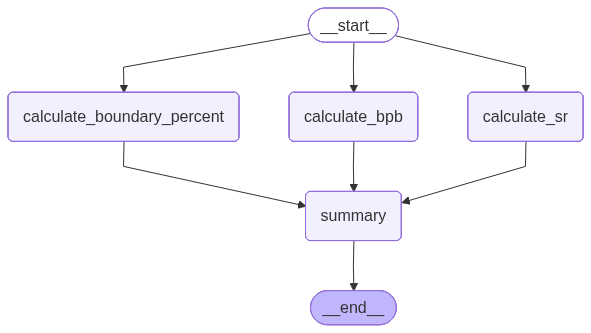

In [8]:
workflow